# Exploratory Data Analysis (EDA)

In this notebook we explore the flight delay dataset to identify patterns and insights related to airline delays, airport congestion, and operational factors.

The analysis includes statistical summaries and visualizations.

In [4]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
plt.style.use("seaborn-v0_8")
sns.set_theme()

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("C:\\Users\\ASUS\\Desktop\\Data_Science_Internship\\Final_Project\\Dataset\\cleaned_flights.csv")

df.head()

,Year,Month,DayofMonth,DayOfWeek,DepTime,ArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,...,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,Delayed,DepHour,ArrHour
0,2008,3,25,2,1124.0,1221.0,WN,1095,N909WN,57.0,...,N,0,0.0,0.0,0.0,0.0,0.0,0,11,12
1,2008,8,9,6,1152.0,1555.0,AA,1690,N5ELAA,183.0,...,N,0,22.0,0.0,13.0,0.0,0.0,1,11,15
2,2008,12,13,6,1226.0,1405.0,EV,5615,N752EV,99.0,...,N,0,0.0,0.0,0.0,0.0,0.0,0,12,13
3,2008,1,21,1,2046.0,2158.0,WN,1274,N642WN,132.0,...,N,0,7.0,0.0,17.0,0.0,49.0,1,19,20
4,2008,12,26,5,1759.0,2026.0,OO,6180,N742SK,87.0,...,N,0,0.0,0.0,0.0,0.0,49.0,1,17,19


In [6]:
df.columns

Index(['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'ArrTime',
       'UniqueCarrier', 'FlightNum', 'TailNum', 'ActualElapsedTime',
       'CRSElapsedTime', 'AirTime', 'ArrDelay', 'DepDelay', 'Origin', 'Dest',
       'Distance', 'TaxiIn', 'TaxiOut', 'Cancelled', 'CancellationCode',
       'Diverted', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay',
       'LateAircraftDelay', 'Delayed', 'DepHour', 'ArrHour'],
      dtype='object')

## Average Arrival Delay by Airline

This visualization shows the **average arrival delay for each airline carrier**.

Insights we are looking for:

- Which airlines experience the **highest average delays**
- Which airlines maintain **better on-time performance**

Understanding airline-level delay patterns can help identify operational inefficiencies and congestion issues.

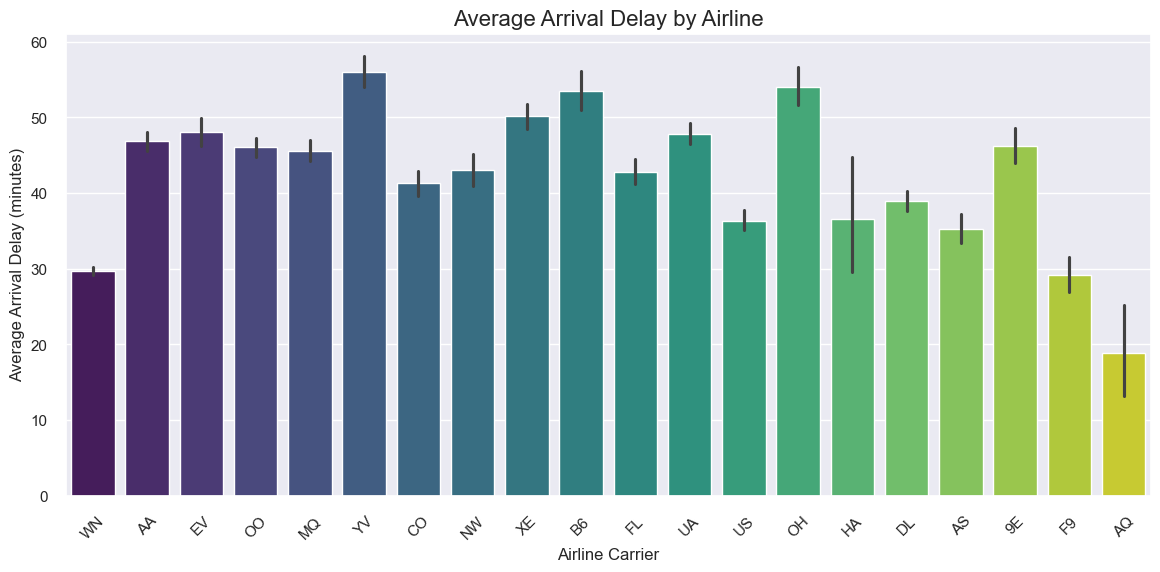

In [7]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=df,
    x="UniqueCarrier",
    y="ArrDelay",
    estimator=np.mean,
    palette="viridis"
)

plt.title("Average Arrival Delay by Airline", fontsize=16)
plt.xlabel("Airline Carrier")
plt.ylabel("Average Arrival Delay (minutes)")
plt.xticks(rotation=45)

plt.show()

## Arrival Delay Distribution by Day of Week

This boxplot shows how arrival delays vary across different days of the week.

The visualization helps identify:

- Whether delays are more frequent on specific days
- Operational congestion patterns across the week

Extreme outliers are removed for clearer visualization.

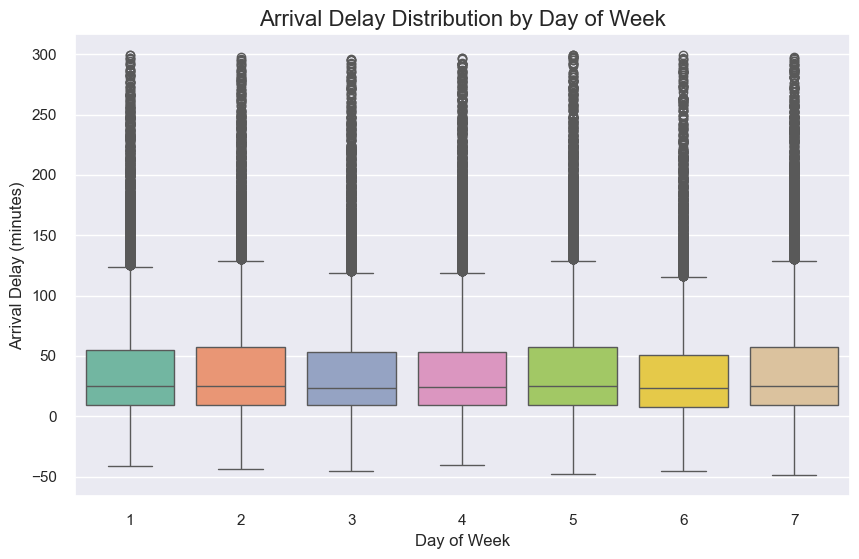

In [8]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df[df["ArrDelay"] < 300],
    x="DayOfWeek",
    y="ArrDelay",
    palette="Set2"
)

plt.title("Arrival Delay Distribution by Day of Week", fontsize=16)
plt.xlabel("Day of Week")
plt.ylabel("Arrival Delay (minutes)")

plt.show()

## Distribution of Arrival Delays

This histogram shows the overall distribution of arrival delays.

Key observations:

- Most flights experience **small delays**
- A smaller number of flights experience **large delays**
- The distribution is **right-skewed**, meaning extreme delays occur but are less frequent.

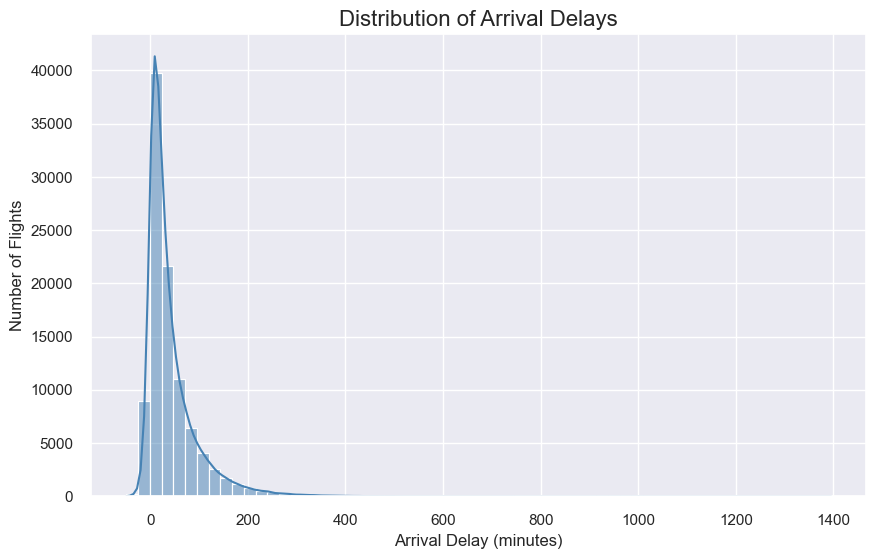

In [9]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["ArrDelay"],
    bins=60,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Arrival Delays", fontsize=16)
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Number of Flights")

plt.show()

## Relationship Between Flight Distance and Arrival Delay

This scatter plot examines whether longer flights tend to experience larger delays.

Each point represents a flight.

Insights we explore:

- Whether delay increases with flight distance
- Presence of extreme delay outliers

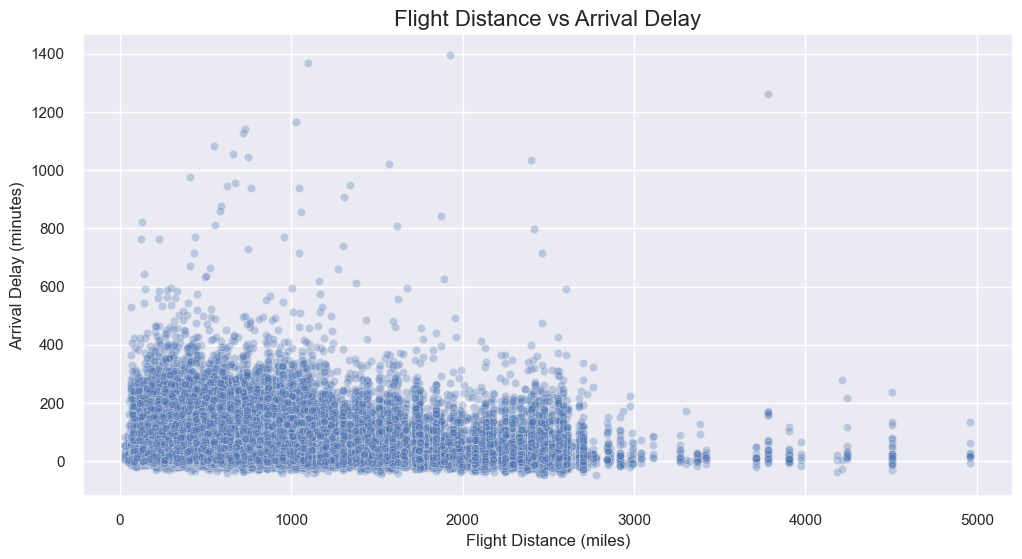

In [10]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df,
    x="Distance",
    y="ArrDelay",
    alpha=0.3
)

plt.title("Flight Distance vs Arrival Delay", fontsize=16)
plt.xlabel("Flight Distance (miles)")
plt.ylabel("Arrival Delay (minutes)")

plt.show()

## Major Causes of Flight Delays

This visualization shows the contribution of different delay causes.

Delay types include:

- Carrier delays
- Weather delays
- Air traffic delays (NAS)
- Security delays
- Late aircraft delays

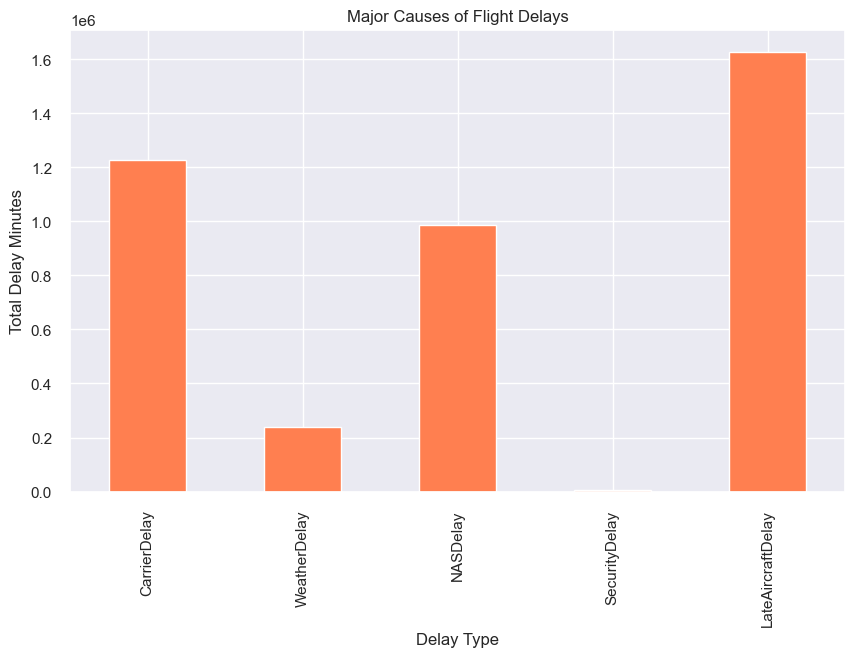

In [11]:
delay_causes = [
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay"
]

df[delay_causes].sum().plot(
    kind="bar",
    figsize=(10,6),
    color="coral"
)

plt.title("Major Causes of Flight Delays")
plt.xlabel("Delay Type")
plt.ylabel("Total Delay Minutes")

plt.show()

## Key Insights from Exploratory Data Analysis

The exploratory data analysis reveals several important patterns in the flight delay dataset.

### 1. Airline Performance
The analysis of average arrival delays across airlines shows that some carriers experience significantly higher delays than others. This indicates that airline-specific operational factors such as fleet management, scheduling efficiency, and airport congestion may contribute to delay variability.

### 2. Weekly Delay Patterns
The boxplot of arrival delays by day of the week suggests that delays are relatively consistent throughout the week, though certain days show slightly higher variability. This may reflect differences in travel demand, airport traffic, and operational load on specific days.

### 3. Distribution of Flight Delays
The delay distribution is highly **right-skewed**, meaning most flights experience small delays while a smaller number of flights experience extremely long delays. These extreme delays represent rare operational disruptions such as severe weather, air traffic congestion, or mechanical issues.

### 4. Distance and Delay Relationship
The scatter plot between flight distance and arrival delay suggests that delay magnitude is not strictly dependent on distance. Both short and long flights can experience delays, though longer flights sometimes show greater variability due to increased exposure to weather and air traffic factors.

### 5. Major Causes of Delays
The delay cause analysis highlights that **carrier delays, air traffic delays (NAS), and late aircraft delays** are among the most significant contributors to overall delay minutes. Weather delays also contribute but generally affect fewer flights compared to operational factors.

### Overall Conclusion
These insights help identify the most influential factors affecting flight delays and guide the feature selection process for the machine learning model used in the prediction phase.